In [5]:
# Standard library imports
import os
import time
import datetime
from collections import defaultdict

# Third-party imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pytz
import joblib
import ta
from fpdf import FPDF
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    f1_score,
    accuracy_score
)
from sklearn.utils import class_weight
import MetaTrader5 as mt5

# TensorFlow / Keras imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, LSTM
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.metrics import Precision, Recall, AUC
from tensorflow.keras.callbacks import EarlyStopping

# Local application imports
from functions.balanced import *
from functions.report import *

from sklearn.ensemble import RandomForestClassifier

In [57]:
data = pd.read_csv('training_data_meta/eurusd_binary_newfeatures.csv')
data = data.drop(['DateTime'], axis=1)

X = data.drop(['label'], axis=1)
y = data['label'].astype(int)

# split_index = int(len(data) * 0.8)
# train_data = data.iloc[:split_index]
# test_data = data.iloc[split_index:]

# xtrain = train_data.drop(['label'], axis=1)
# ytrain = test_data['label'].astype(int)

# xtest = test_data.drop(['label'], axis=1)
# ytest = test_data['label'].astype(int)

# tec_indicators: only the technical indicator columns
tec_indicators = X[['rsi', 'macd', 'body', 'atr', 'adx']]
X = X.drop(['rsi', 'macd', 'body', 'atr', 'adx'], axis=1)

Only start trading at 08:10 and stop opening trades at 21

In [ ]:
# Initialize
X_full = X.copy()
X_full['pred'] = np.nan
X_full['trade_pnl'] = 0.0
X_full['lot_size'] = 0.0
X_full['trade_open'] = False
X_full['balance'] = np.nan

# Parameters
sequence_length = 12
window_size = 10000
val_size = 3000
step = 3000
cost_per_trade = 3.26 # review this, it can be changed to be in euros    
pip_value_per_standard_lot = 10
initial_account_balance = 10000.0
risk_per_trade_percentage = 0.01
steps = 12 # ver se isto influencia, meti todas as funções dependentes desta variável
extra_steps = 0
class_to_direction = {0: 0, 1: 1}
threshold = 0.85

# Tracking
current_account_balance = initial_account_balance
f1_per_window, profit_per_window, trade_per_window, window_indices = [], [], [], []
vol_per_window, local_vol_per_window, losing_profit, winning_profit, reports = [], [], [], [], []
train_distributions = []
val_distributions = []
epoch_counts = []
reports_1 = []
atr_per_window, adx_per_window, macd_per_window, rsi_per_window = [], [], [], []

profit_per_class = defaultdict(float)
trades_per_class = defaultdict(int)
winning_trades, losing_trades = 0, 0

# to remove bad trades
X_full['flag'] = X_full['hour'].isin([8, 21]) # find a way to flag the 8h10 trades also
columns_to_drop = ['pred', 'trade_pnl', 'lot_size', 'trade_open', 'balance', 'flag']

for w, start in enumerate(range(0, len(X_full) - window_size - val_size - steps, step)):
    print(f"\n Window {w}")

    # Split
    train_X_slice = X_full.iloc[start : start + window_size]
    train_y = y[start : start + window_size]

    val_X_slice = X_full.iloc[start + window_size : start + window_size + val_size]
    indicators = tec_indicators.iloc[start + window_size : start + window_size + val_size]
    val_y = y[start + window_size : start + window_size + val_size]

    train_flag = train_X_slice['flag']
    val_flag = val_X_slice['flag']

    train_X = train_X_slice.drop(columns=columns_to_drop)
    val_X = val_X_slice.drop(columns=columns_to_drop)

    # Standardize
    scaler = MinMaxScaler()
    train_X_scaled = scaler.fit_transform(train_X)
    val_X_scaled = scaler.fit_transform(val_X)

    train_X_seq, train_y_seq = create_lstm_sequences(train_X_scaled, train_y.values, sequence_length)
    val_X_seq, val_y_seq = create_lstm_sequences(val_X_scaled, val_y.values, sequence_length)

    train_flag_targets = train_flag[sequence_length:]
    val_flag_targets = val_flag[sequence_length:]
    # Filter out sequences where target point was flagged
    train_mask = train_flag_targets == 0
    val_mask = val_flag_targets == 0

    train_X_seq = train_X_seq[train_mask]
    train_y_seq = train_y_seq[train_mask]

    '''train_y_cat = to_categorical(train_y_seq, num_classes=3)
    val_y_cat = to_categorical(val_y_seq, num_classes=3)'''
    train_y_cat = train_y_seq.copy()
    val_y_cat = val_y_seq.copy()

    # Build & train model
    input_features = train_X_seq.shape[2]
    sequence_length = train_X_seq.shape[1]
    model = build_model_rnn(sequence_length, input_features)

    cw = dict(enumerate(class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(train_y_seq), y=train_y_seq)))
    # cw = {0: 1, 1: 100} # fine tune this
    # early_stop = EarlyStopping(
    #     monitor='val_loss',  # or 'val_accuracy'
    #      patience=5,          # wait 5 epochs for improvement
    #      restore_best_weights=True
    #  )
    # val_X_seq = val_X_seq[val_mask]
    # val_y_cat = val_y_cat[val_mask]

    history = model.fit(train_X_seq, train_y_cat,
            epochs=10, batch_size=32,  class_weight=cw,
            verbose=0, shuffle=False) #, callbacks=[early_stop])
    
    # Store how many epochs were used
    # used_epochs = len(history.history['loss'])
    # epoch_counts.append(used_epochs)

    # Predict
    #Prevê a melhor class e guarda a confiança
    preds_probs = model.predict(val_X_seq, verbose=0)
    # preds = np.argmax(preds_probs, axis=1)
    # confidences = np.max(preds_probs, axis=1)
    preds = (preds_probs.flatten() >= threshold).astype(int)
    confidences = preds_probs.flatten()

    # Set prediction to 0 if confidence < 0.7
    # preds = np.where(confidences >= threshold, preds, 0)

    val_start = start + window_size
    adjusted_start = val_start + sequence_length
    max_len = min(len(preds), len(X_full) - adjusted_start)
    pred_indices = range(adjusted_start, adjusted_start + len(preds))

    #armazena na df
    X_full.loc[pred_indices, 'pred'] = preds[:max_len]
    X_full.loc[pred_indices, 'confidence'] = confidences[:max_len]

    f1_preds = preds[val_mask]
    f1_val = val_y_seq[val_mask]

    get_val = val_X[sequence_length:]
    get_val = get_val[val_mask]

    indicators = indicators[sequence_length:]
    indicators = indicators[val_mask]

    # Compute indicators
    atr = indicators['atr'].mean()
    adx = indicators['adx'].mean()
    macd = indicators['macd'].mean()
    rsi = indicators['rsi'].mean()
    # Append mean values to per-window lists
    atr_per_window.append(atr)
    adx_per_window.append(adx)
    macd_per_window.append(macd)
    rsi_per_window.append(rsi)

    unique, counts = np.unique(train_y_seq, return_counts=True)
    train_distribution = dict(zip(unique, counts))

    unique_val, counts_val = np.unique(val_y_cat, return_counts=True)
    val_distribution = dict(zip(unique_val, counts_val))

    sl_tp_map = {
            0: {'sl': None, 'tp': None},
            1: {'sl': 15, 'tp': 15}
        }
      
    avg_duration_by_class = {
            0: None,
            1: 12
        }           

    # Trade Simulation
    min_broker_lot_size = 0.01
    max_broker_lot_size = 50.0
    profit = 0.0
    trades = 0
    last_trade_close_idx = -1

    for i, t in enumerate(pred_indices):

        flag = X_full.at[t, 'flag']
        if flag == 1:
            continue

        if np.isnan(X_full.at[t, 'pred']):
            continue
        if t < last_trade_close_idx:
            continue

        pred = int(X_full.at[t, 'pred'])
        direction = class_to_direction.get(pred, 0)
        if direction == 0: # or direction == -1:
            continue

        sltp = sl_tp_map.get(pred, {'sl': None, 'tp': None})
        if sltp['sl'] is None or sltp['tp'] is None or sltp['sl'] <= 0:
            continue  

        monetary_risk = current_account_balance * risk_per_trade_percentage
        lot_size = monetary_risk / (sltp['sl'] * pip_value_per_standard_lot)
        lot_size = round(min(max(lot_size, min_broker_lot_size), max_broker_lot_size), 2)
        if lot_size < 0.01:
            continue
        
        entry = X_full.at[t + 1, 'Open']
        highs_seq = X_full['High'].iloc[t + 1 : t + 1 + steps].values
        lows_seq = X_full['Low'].iloc[t + 1 : t + 1 + steps].values
        limit = avg_duration_by_class.get(pred, 0) + extra_steps

        result_pips, rel_exit_idx = simulate_trade(entry, highs_seq[:limit], lows_seq[:limit], direction, sltp['sl'], sltp['tp'])
        result_pips -= cost_per_trade

        trade_profit = result_pips * pip_value_per_standard_lot * lot_size
        profit += trade_profit
        trades += 1
        current_account_balance += trade_profit
        last_trade_close_idx = t + rel_exit_idx

        X_full.at[t, 'trade_open'] = True
        X_full.at[t, 'trade_pnl'] = trade_profit
        X_full.at[t, 'lot_size'] = lot_size
        X_full.at[t, 'balance'] = current_account_balance

        profit_per_class[pred] += trade_profit
        trades_per_class[pred] += 1
        if result_pips > 0:
            winning_trades += 1
            winning_profit.append(trade_profit)
        elif result_pips < 0:
            losing_trades += 1
            losing_profit.append(trade_profit)

    # Track metrics
    vol = get_val['Close'].pct_change().std()
    vol_local = get_val['vol_local'].mean()

    report = classification_report(f1_val, f1_preds, digits=3)
    f1 = f1_score(f1_val, f1_preds, average='weighted')
    f1_per_window.append(f1)
    profit_per_window.append(profit)
    trade_per_window.append(trades)
    window_indices.append(w)
    vol_per_window.append(vol)
    local_vol_per_window.append(vol_local)
    reports.append(report)
    train_distributions.append(train_distribution)
    val_distributions.append(val_distribution)

    '''# For training data (train set, not validation)
    train_start = start
    adjusted_train_start = train_start + sequence_length
    max_train_len = len(train_y_seq)
    train_pred_indices = range(adjusted_train_start, adjusted_train_start + max_train_len)
    
    preds_probs_1 = model.predict(train_X_seq, verbose=0)
    preds_1 = np.argmax(preds_probs_1, axis=1)
    confidences_1 = np.max(preds_probs_1, axis=1)

    f1_1 = f1_score(train_y.iloc[:max_train_len], preds_1[:max_train_len], average='weighted')
    report_1 = classification_report(train_y.iloc[:max_len], preds_1[:max_len], digits=4)

    reports_1.append(report_1)
'''
    print(f"Profit: {profit:.2f}, Trades: {trades}, F1: {f1:.3f}, Balance: {current_account_balance:.2f}")


 Window 0
Profit: 821.40, Trades: 19, F1: 0.933, Balance: 10821.40

 Window 1
Profit: 361.20, Trades: 8, F1: 0.965, Balance: 11182.60

 Window 2
Profit: 586.64, Trades: 7, F1: 0.914, Balance: 11769.24

 Window 3
Profit: 184.32, Trades: 2, F1: 0.952, Balance: 11953.56

 Window 4
Profit: 671.53, Trades: 7, F1: 0.960, Balance: 12625.09

 Window 5
Profit: 399.16, Trades: 4, F1: 0.890, Balance: 13024.25

 Window 6
Profit: 560.28, Trades: 7, F1: 0.917, Balance: 13584.52

 Window 7
Profit: 1074.81, Trades: 15, F1: 0.945, Balance: 14659.33

 Window 8
Profit: -1066.34, Trades: 36, F1: 0.837, Balance: 13593.00

 Window 9
Profit: 384.76, Trades: 15, F1: 0.940, Balance: 13977.75

 Window 10
Profit: -763.62, Trades: 27, F1: 0.898, Balance: 13214.13

 Window 11
Profit: 62.41, Trades: 32, F1: 0.818, Balance: 13276.55

 Window 12
Profit: 3.61, Trades: 6, F1: 0.915, Balance: 13280.16

 Window 13
Profit: 208.97, Trades: 2, F1: 0.932, Balance: 13489.13

 Window 14
Profit: 189.71, Trades: 6, F1: 0.869, B

c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Profit: 0.00, Trades: 0, F1: 0.904, Balance: 17798.27

 Window 29
Profit: 247.49, Trades: 3, F1: 0.987, Balance: 18045.76

 Window 30
Profit: 275.43, Trades: 4, F1: 0.983, Balance: 18321.19

 Window 31
Profit: 287.63, Trades: 2, F1: 0.981, Balance: 18608.82

 Window 32
Profit: 637.35, Trades: 5, F1: 0.972, Balance: 19246.17

 Window 33
Profit: 41.74, Trades: 5, F1: 0.967, Balance: 19287.92

 Window 34
Profit: -627.07, Trades: 16, F1: 0.875, Balance: 18660.85

 Window 35
Profit: 966.19, Trades: 7, F1: 0.978, Balance: 19627.03

 Window 36
Profit: 814.32, Trades: 8, F1: 0.943, Balance: 20441.35

 Window 37
Profit: 1382.50, Trades: 11, F1: 0.956, Balance: 21823.85

 Window 38
Profit: 1208.51, Trades: 7, F1: 0.951, Balance: 23032.36

 Window 39
Profit: 129.15, Trades: 4, F1: 0.950, Balance: 23161.51

 Window 40
Profit: -320.38, Trades: 14, F1: 0.854, Balance: 22841.13

 Window 41


c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

Profit: -679.34, Trades: 11, F1: 0.945, Balance: 22161.79

 Window 42
Profit: 111.01, Trades: 2, F1: 0.956, Balance: 22272.80

 Window 43
Profit: 118.16, Trades: 24, F1: 0.833, Balance: 22390.96

 Window 44
Profit: -1363.30, Trades: 41, F1: 0.743, Balance: 21027.66

 Window 45
Profit: 164.36, Trades: 1, F1: 0.940, Balance: 21192.02

 Window 46
Profit: -636.47, Trades: 19, F1: 0.864, Balance: 20555.55

 Window 47
Profit: -877.51, Trades: 30, F1: 0.767, Balance: 19678.04

 Window 48
Profit: 133.94, Trades: 7, F1: 0.958, Balance: 19811.98

 Window 49
Profit: -214.75, Trades: 24, F1: 0.804, Balance: 19597.23

 Window 50
Profit: -199.10, Trades: 43, F1: 0.614, Balance: 19398.13

 Window 51
Profit: 1466.58, Trades: 15, F1: 0.929, Balance: 20864.71

 Window 52
Profit: -81.71, Trades: 25, F1: 0.880, Balance: 20783.00

 Window 53
Profit: 240.68, Trades: 22, F1: 0.882, Balance: 21023.69

 Window 54
Profit: 574.38, Trades: 22, F1: 0.860, Balance: 21598.06

 Window 55
Profit: 901.50, Trades: 13, F

c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Profit: 0.00, Trades: 0, F1: 0.910, Balance: 22499.56

 Window 57
Profit: 445.07, Trades: 5, F1: 0.978, Balance: 22944.63

 Window 58
Profit: -11.94, Trades: 8, F1: 0.965, Balance: 22932.69

 Window 59
Profit: 179.62, Trades: 1, F1: 0.994, Balance: 23112.31

 Window 60
Profit: 388.99, Trades: 4, F1: 0.962, Balance: 23501.30

 Window 61
Profit: 1562.76, Trades: 18, F1: 0.878, Balance: 25064.06

 Window 62


c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\marti\anaconda3\envs\quant-trading\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Profit: 0.00, Trades: 0, F1: 0.836, Balance: 25064.06

 Window 63
Profit: 2627.26, Trades: 18, F1: 0.889, Balance: 27691.32

 Window 64
Profit: 1210.76, Trades: 9, F1: 0.898, Balance: 28902.09

 Window 65
Profit: 991.00, Trades: 15, F1: 0.913, Balance: 29893.08

 Window 66
Profit: 750.07, Trades: 7, F1: 0.902, Balance: 30643.15

 Window 67
Profit: 935.04, Trades: 4, F1: 0.931, Balance: 31578.19

 Window 68
Profit: 1882.88, Trades: 10, F1: 0.930, Balance: 33461.07

 Window 69
Profit: 2899.05, Trades: 15, F1: 0.901, Balance: 36360.12

 Window 70
Profit: 2798.27, Trades: 10, F1: 0.954, Balance: 39158.39

 Window 71
Profit: 765.49, Trades: 19, F1: 0.820, Balance: 39923.88

 Window 72
Profit: 3899.48, Trades: 15, F1: 0.926, Balance: 43823.36

 Window 73
Profit: 1036.64, Trades: 3, F1: 0.849, Balance: 44860.00

 Window 74
Profit: 4190.47, Trades: 30, F1: 0.802, Balance: 49050.47

 Window 75
Profit: 5015.18, Trades: 22, F1: 0.923, Balance: 54065.65

 Window 76
Profit: 3988.34, Trades: 10, F1:

In [64]:
j = 0
for i in epoch_counts:
    j += i
m = j/len(epoch_counts)

print(f"Total epochs used: {m}")


Total epochs used: 9.733333333333333


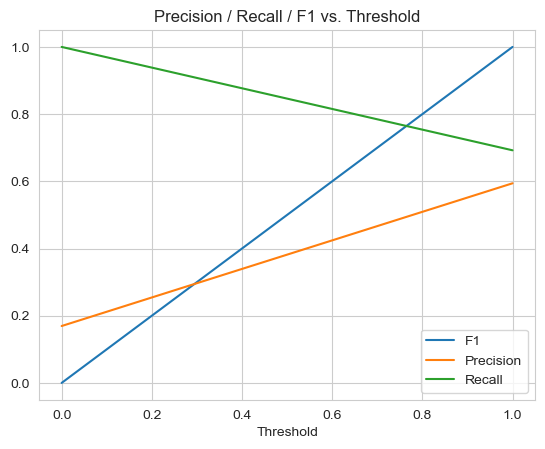

In [25]:
plt.plot(ths, [0,1], label='F1')
plt.plot(ths, prec[:-1], label='Precision')
plt.plot(ths, rec[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.title('Precision / Recall / F1 vs. Threshold')
plt.grid(True)
plt.show()

In [68]:
generate_model_report_pdf(
    steps,
    extra_steps,
    window_indices,
    f1_per_window,
    profit_per_window,
    trade_per_window,
    vol_per_window,
    local_vol_per_window,
    losing_profit,
    winning_profit,
    initial_account_balance,
    window_size,
    val_size,
    step,
    cost_per_trade,
    pip_value_per_standard_lot,
    risk_per_trade_percentage,
    winning_trades,
    losing_trades,
    profit_per_class,
    trades_per_class,
    threshold,
    train_distributions,
    val_distributions,
    atr_per_window,
    adx_per_window,
    macd_per_window,
    rsi_per_window,
    report_filename="model_eurusd_10k_10_1k.pdf"
)

C:\Users\marti\AppData\Local\Temp\ipykernel_9804\2539186095.py:172: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "B", 16)
C:\Users\marti\AppData\Local\Temp\ipykernel_9804\2539186095.py:173: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, "Trading Model Performance Report", 0, 1, "C")
C:\Users\marti\AppData\Local\Temp\ipykernel_9804\2539186095.py:174: DeprecationWarning: Substituting font arial by core font helvetica - This is deprecated since v2.7.8, and will soon be removed
  pdf.set_font("Arial", "", 10)
C:\Users\marti\AppData\Local\Temp\ipykernel_9804\2539186095.py:175: DeprecationWarning: The parameter "ln" is deprecated since v2.5.2. Instead of ln=1 use new_x=XPos.LMARGIN, new_y=YPos.NEXT.
  pdf.cell(0, 10, f"Date: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M')}", 0, 1, "C")
C:\Users\


Report generated successfully: model_eurusd_10k_10_1k.pdf


In [12]:
print(reports[6])

              precision    recall  f1-score   support

           0      0.000     0.000     0.000      7389
           1      0.153     1.000     0.266      1339

    accuracy                          0.153      8728
   macro avg      0.077     0.500     0.133      8728
weighted avg      0.024     0.153     0.041      8728

